In [1]:
import sys
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

In [ ]:
from iter_refine.quadratic_lin_approx_no_surrogate_iter import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from iter_refine.classical_solve_lin_program_iter import solve_lp # type: ignore[reportMissingImports]
from testers.classical_solve_quad_program import solve_qcp # type: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

In [35]:
# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

In [36]:
# Put the original QCP into gurobi
qcp_value, qcp_time = solve_qcp(f_name="model11_quad_reform_2.json")
print(qcp_value, qcp_time)

4692.145737713451 0.0009999275207519531


In [37]:
print(solve_lp(f_name="Model11_lp.json"))
print(solve_qcp(f_name="Model11_lp.json"))

(4587.929636019629, 0.0009999275207519531)
(4587.929636019691, 0.0)


2.5971700612617497
127.18473501676544


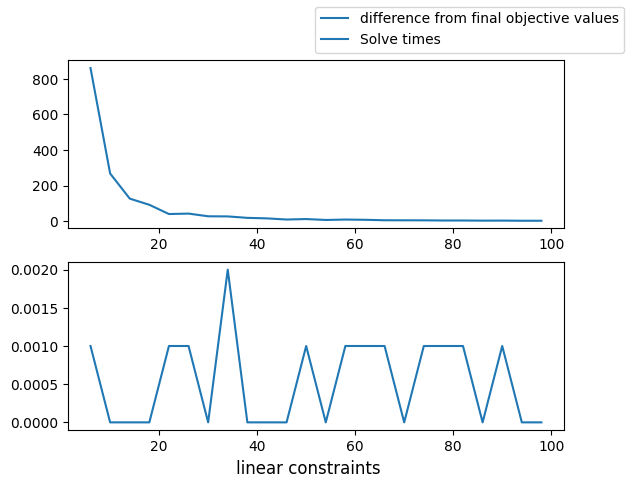

In [ ]:
errors = []
times = []

# Model may be infeasible if this is not big enough
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)

for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             f_name="model11_quad_reform_2.json", remove_division=REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        f_name="model11_quad_reform_2.json", remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

In [32]:
concat = 1.67

def np_uniform_bunch_low(lower: float, upper: float, num: int):
    return np.linspace(lower, lower + ((upper - lower)/concat), num)

def np_uniform_bunch_high(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / concat), upper, num)

def np_uniform_bunch_middle(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / (2*concat)), lower + ((upper - lower)/(2*concat)), num)

-0.23357992906403524
-51.330132703254094


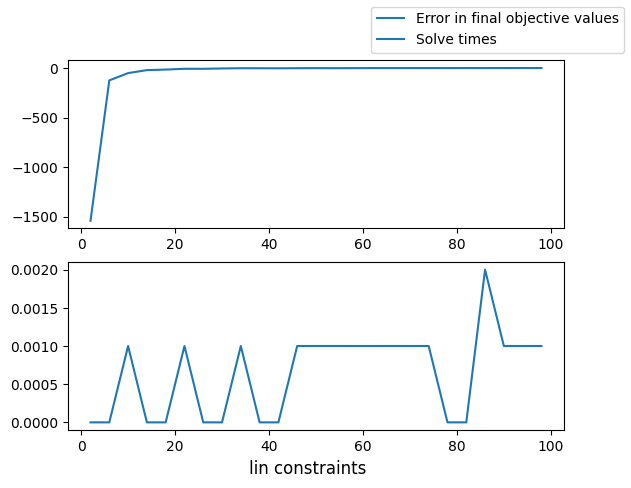

In [17]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-1541.5870024185542
-1541.5870024185542


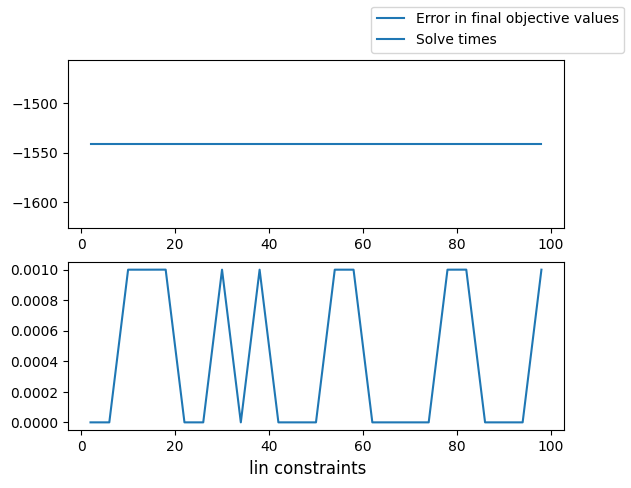

In [ ]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-1509.0588940506723
-1509.0588940506723


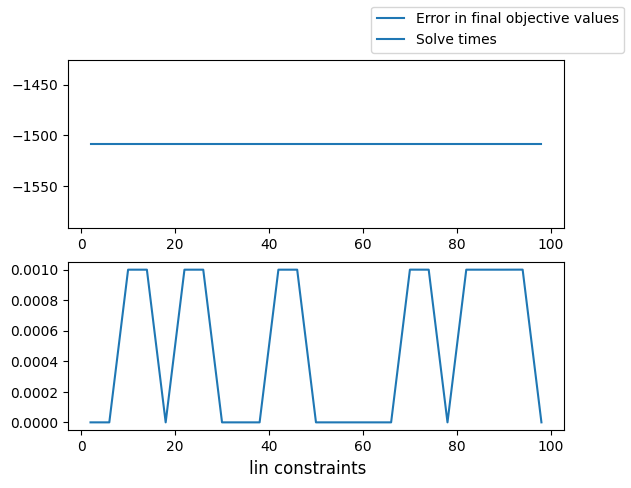

In [ ]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

1.659118236472946


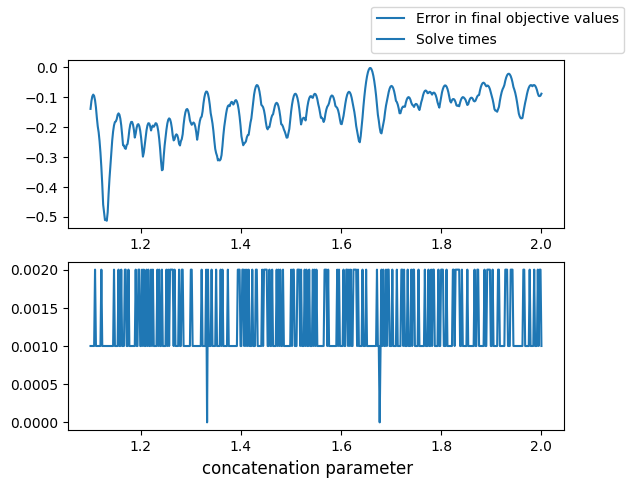

In [11]:
points = np.linspace(1.1, 2, 500, endpoint=True)
LIN_CONSTRAINTS = 200

errors = []
times = []
for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.linspace(lower, lower + ((upper - lower)/concat), num)

    
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform.json")
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION,
                                        points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad_reform.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("concatenation parameter")
ax1.plot(points, errors, label="Error in final objective values")
ax2.plot(points, times, label="Solve times")
fig.legend()

print(points[np.argmin(np.abs(errors))])